In [41]:
import pandas as pd
import seaborn as sns

In [7]:
df = pd.read_csv("../datasets/titanic/titanic.csv")

In [6]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Questions

## 1 How big is the data

In [9]:
df.shape

(891, 12)

## 2 How does the data look like

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
df.sample(5) # randomly pick rows from the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
316,317,1,2,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1,0,244367,26.0000,NaN,S
562,563,0,2,"Norman, Mr. Robert Douglas",male,28.0,0,0,218629,13.5000,NaN,S
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,NaN,S


## 3 what is the datatype of columns

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 4. Are there any missing values

In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 5. How does the data look mathematically

In [29]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 6. Are there any duplicated values

In [30]:
df.duplicated().sum()

0

## 7. How is the correlated b/w columns

In [33]:
df.select_dtypes(include='number').corr()["Age"]

PassengerId    0.036847
Survived      -0.077221
Pclass        -0.369226
Age            1.000000
SibSp         -0.308247
Parch         -0.189119
Fare           0.096067
Name: Age, dtype: float64

# Univarient Data Analysis

## 1 Categorical Data

### a. Countplot

Survived
0    549
1    342
Name: count, dtype: int64

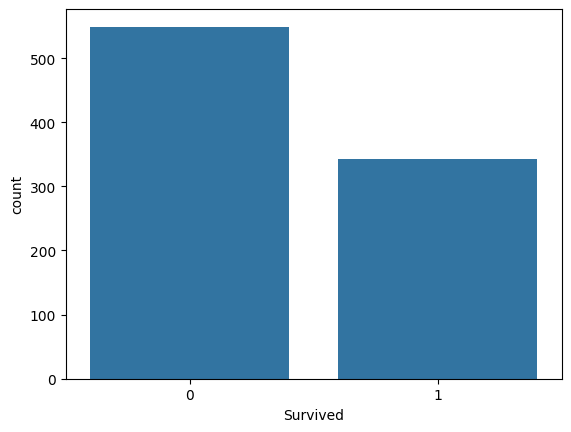

In [45]:
sns.countplot(x="Survived",data=df)
df["Survived"].value_counts()
# we show the counts of obs in each category

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

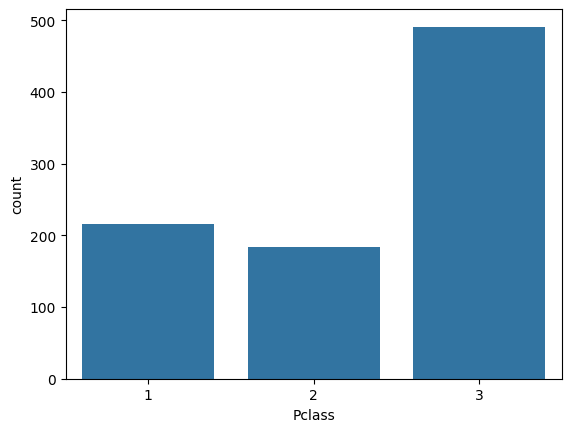

In [49]:
sns.countplot(x='Pclass',data=df)
df['Pclass'].value_counts()

<Axes: xlabel='Sex', ylabel='count'>

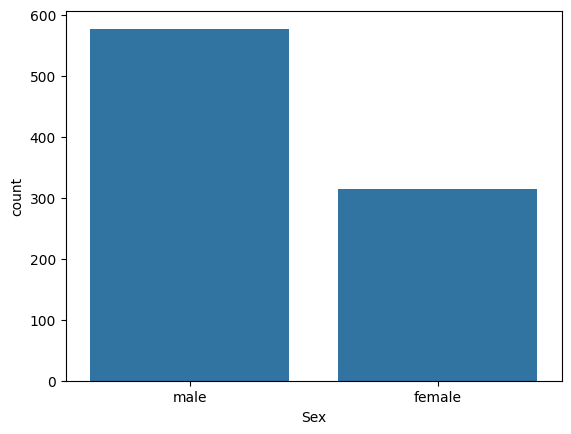

In [50]:
sns.countplot(x="Sex",data=df)

<Axes: xlabel='Embarked', ylabel='count'>

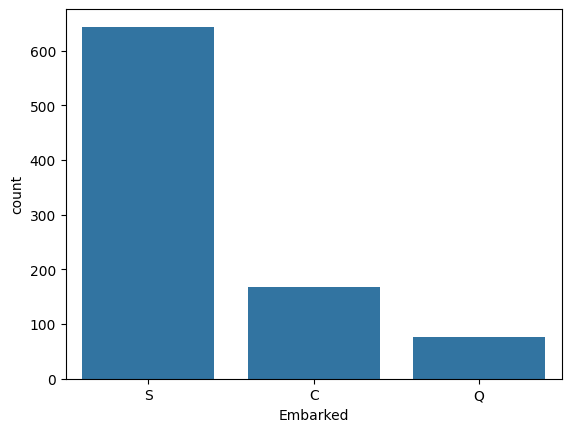

In [51]:
sns.countplot(x='Embarked', data=df)

<Axes: ylabel='count'>

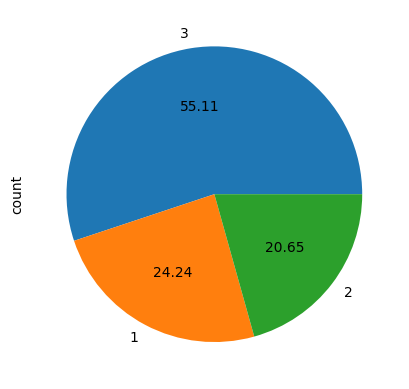

In [54]:
df["Pclass"].value_counts().plot(kind='pie', autopct="%.2f")

## 2.Numerical Data

### a. Histogram

The whole idea of the histogram is to understand the distribution of data in numberical format

(array([24.,  6., 14.,  3.,  7.,  8.,  6.,  3.,  7., 22., 13., 51., 40.,
        27., 46., 24., 36., 47., 27., 35., 17., 34., 29., 11., 27.,  8.,
        18.,  9., 17., 18.,  6., 17.,  6.,  9.,  7.,  2.,  7.,  4.,  7.,
         4.,  3.,  1.,  0.,  2.,  3.,  0.,  1.,  0.,  0.,  1.]),
 array([ 0.42  ,  2.0116,  3.6032,  5.1948,  6.7864,  8.378 ,  9.9696,
        11.5612, 13.1528, 14.7444, 16.336 , 17.9276, 19.5192, 21.1108,
        22.7024, 24.294 , 25.8856, 27.4772, 29.0688, 30.6604, 32.252 ,
        33.8436, 35.4352, 37.0268, 38.6184, 40.21  , 41.8016, 43.3932,
        44.9848, 46.5764, 48.168 , 49.7596, 51.3512, 52.9428, 54.5344,
        56.126 , 57.7176, 59.3092, 60.9008, 62.4924, 64.084 , 65.6756,
        67.2672, 68.8588, 70.4504, 72.042 , 73.6336, 75.2252, 76.8168,
        78.4084, 80.    ]),
 <BarContainer object of 50 artists>)

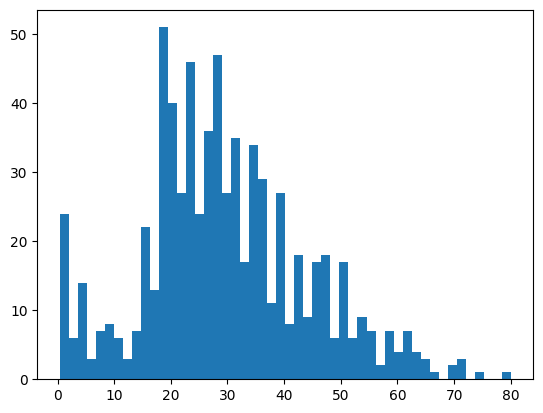

In [58]:
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=50)

### b. Distplt

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_78811/363678278.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

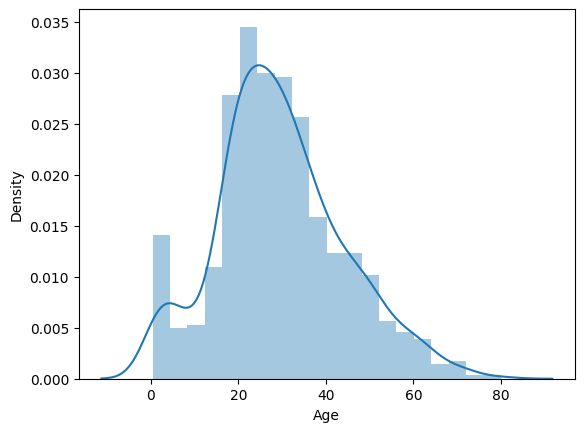

In [62]:
sns.distplot(df['Age'])


# PDF(probability density function) is a function that describes the likelihood of a random variable to take on a particular value.
# It is used to describe the distribution of continuous random variables.

# KAD(kernel density estimation) is a way to estimate the probability density function of a random variable. 
# It is a non-parametric way to estimate the distribution of data points in a continuous space.

In [63]:
df["Age"].skew()

0.38910778230082704

<Axes: ylabel='Age'>

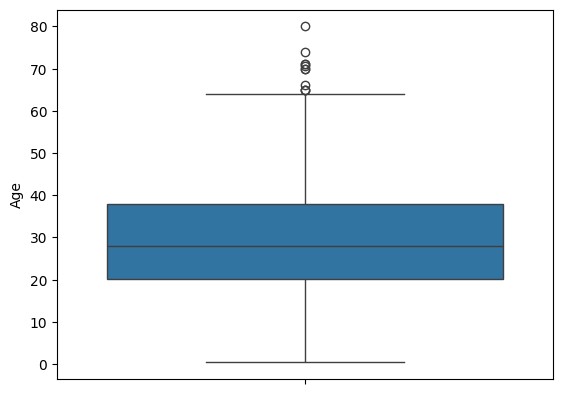

In [66]:
sns.boxplot(df["Age"])

# used when we want to find outliers in the data

In [67]:
df["Age"].min()

0.42

In [68]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

# Multivarient Analysis

In [70]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [72]:
titanic_df = sns.load_dataset("titanic")
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [74]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [75]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Scatterplot - Numerical 

<Axes: xlabel='total_bill', ylabel='tip'>

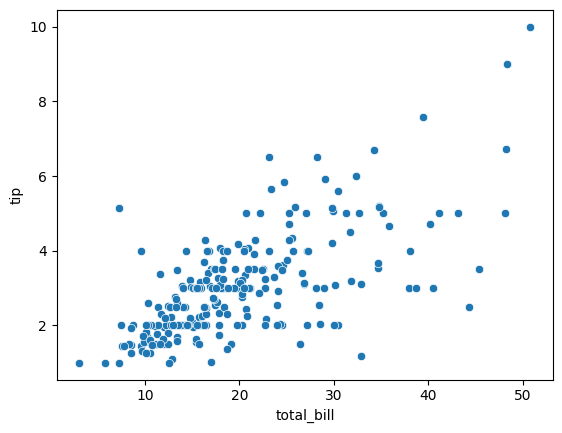

In [78]:
sns.scatterplot(data=tips, x="total_bill", y="tip")

<Axes: xlabel='total_bill', ylabel='tip'>

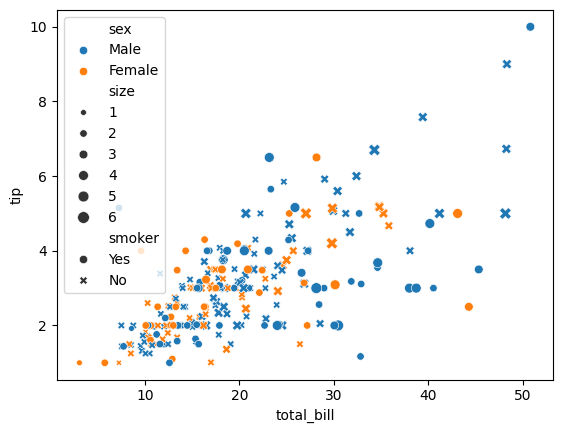

In [86]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", style="smoker", size="size")

## 2. Bar plot (Numerical - Categorial)


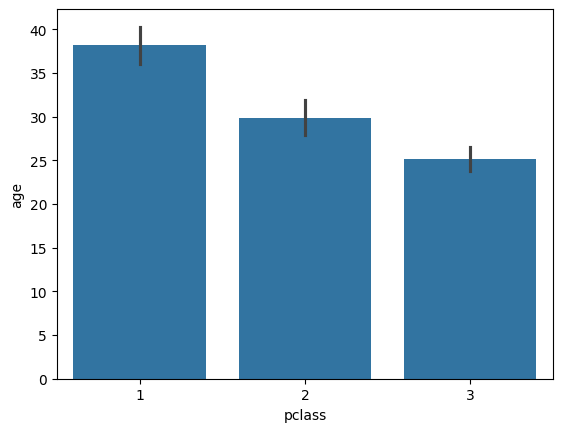

In [90]:
sns.barplot(x="pclass", y="age", data=titanic_df)
plt.show()

<Axes: xlabel='pclass', ylabel='fare'>

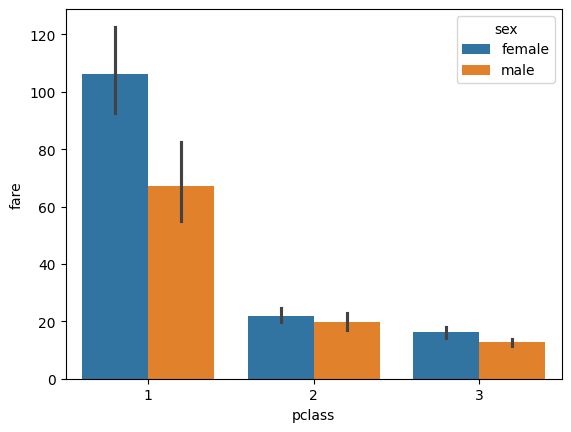

In [94]:
sns.barplot(x="pclass", y="fare", hue="sex", data=titanic_df)

## 3. Box plot - (Numerial - Categorial)

<Axes: xlabel='sex', ylabel='age'>

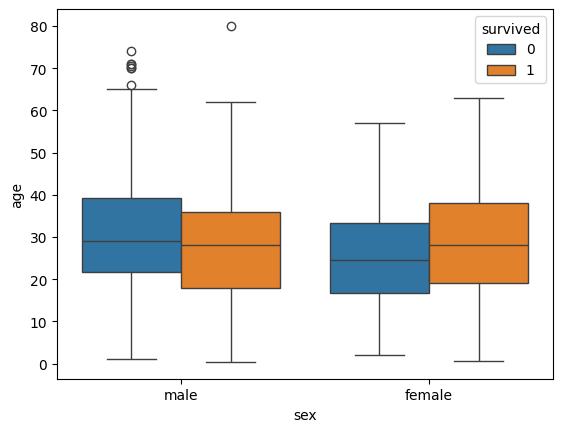

In [95]:
sns.boxplot(x="sex",y="age",hue="survived",data=titanic_df)

## 4. Displot (Numerical - Categorical)

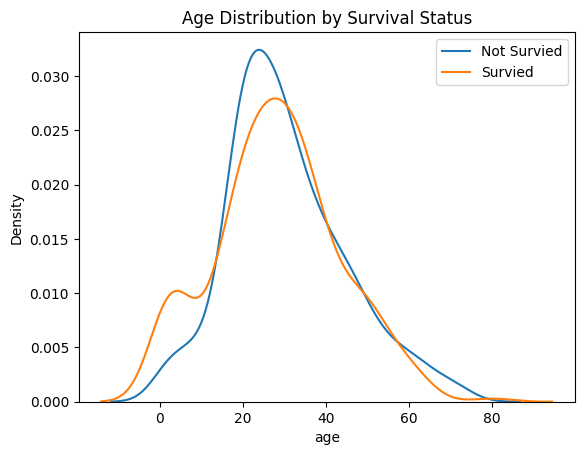

In [101]:
sns.kdeplot(
    data=titanic_df[titanic_df["survived"] == 0],
    x="age",
    label="Not Survied"
)

sns.kdeplot(
    data=titanic_df[titanic_df["survived"] == 1],
    x="age",
    label="Survied"
)

plt.legend()
plt.title("Age Distribution by Survival Status")
plt.show()

## 5. Heatmap (Categorical - Categorical)

In [102]:
titanic_df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [104]:
pd.crosstab(titanic_df["pclass"],titanic_df["survived"])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='survived', ylabel='pclass'>

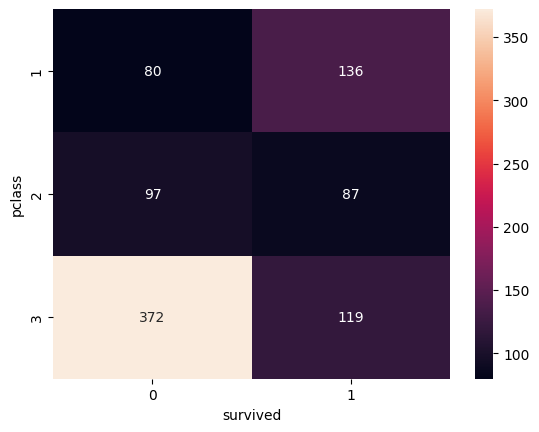

In [107]:
sns.heatmap(pd.crosstab(titanic_df["pclass"], titanic_df["survived"]), annot=True, fmt="d")

In [111]:
titanic_df.groupby('embarked')["survived"].mean()*100

embarked
C    55.357143
Q    38.961039
S    33.695652
Name: survived, dtype: float64

## 6. ClusterMap (Categorical - Categorical)

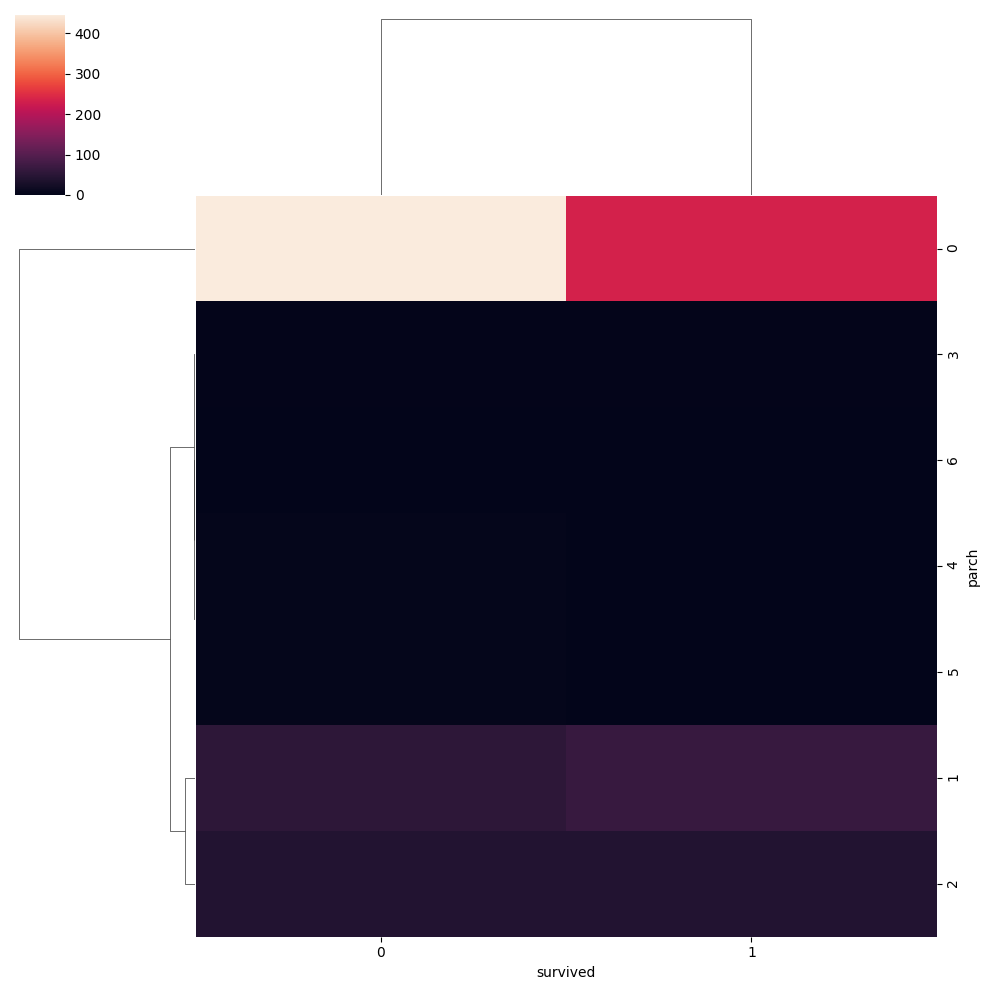

In [114]:
sns.clustermap(pd.crosstab(titanic_df["parch"], titanic_df["survived"]))

## 7. Pairplot

It is collection of scatter plots. If you have multiple numerical columns and you want to see connection between one numerical column to another.
For that purpose we use pairplot

In [115]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


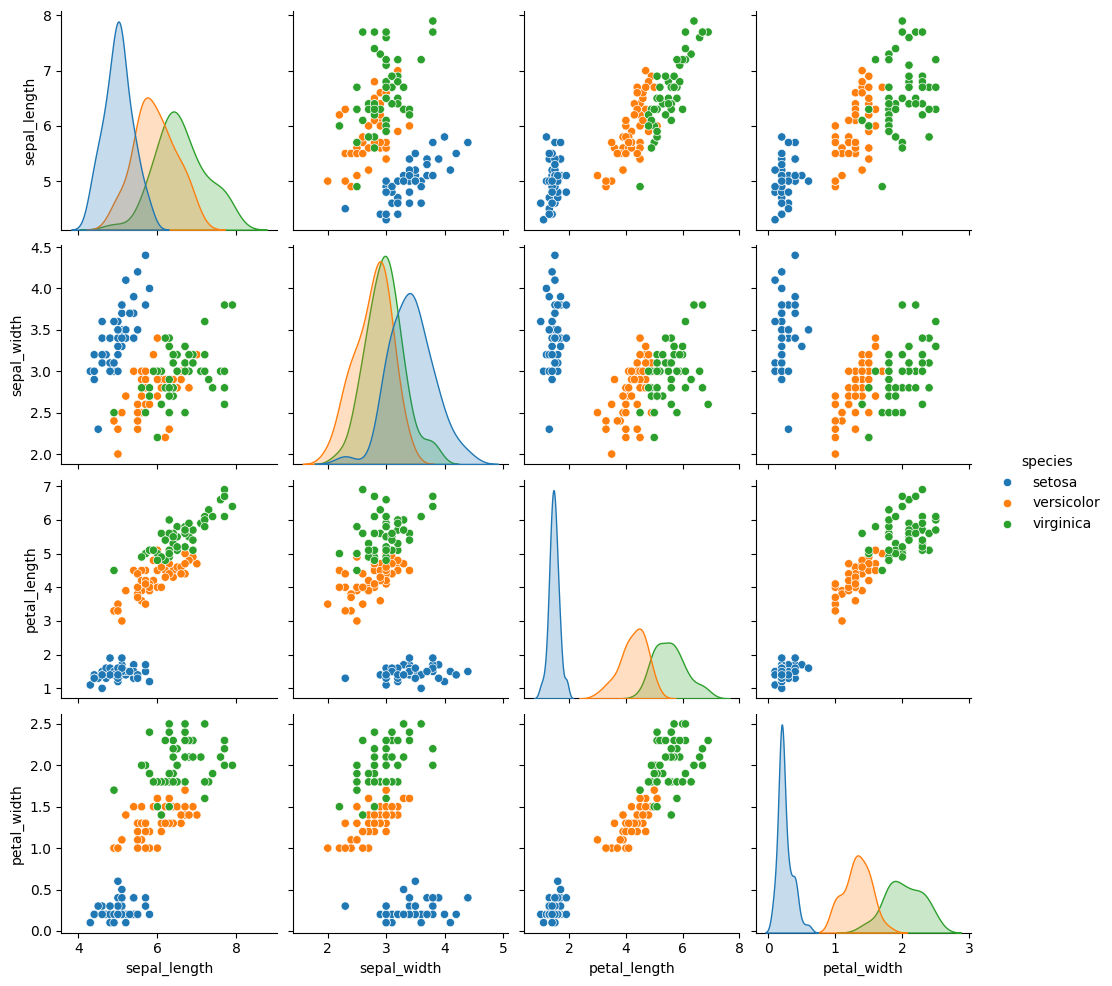

In [117]:
sns.pairplot(iris, hue="species")

## Lineplot (Numerical - Numerical)

In [119]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [122]:
new = flights.groupby('year')['passengers'].sum().reset_index()

<Axes: xlabel='year', ylabel='passengers'>

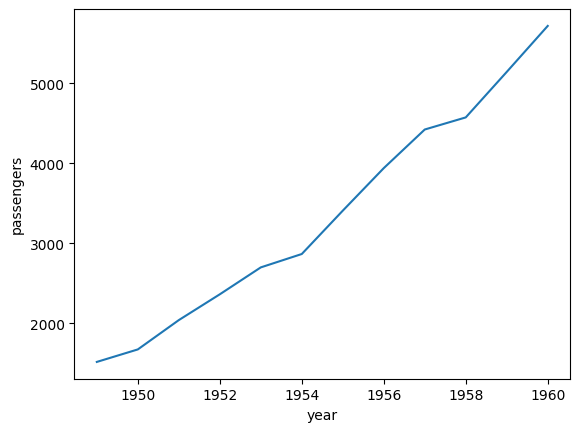

In [123]:
sns.lineplot(x="year", y="passengers", data=new)

Text(0.5, 1.0, 'Number of Passengers per Month and Year')

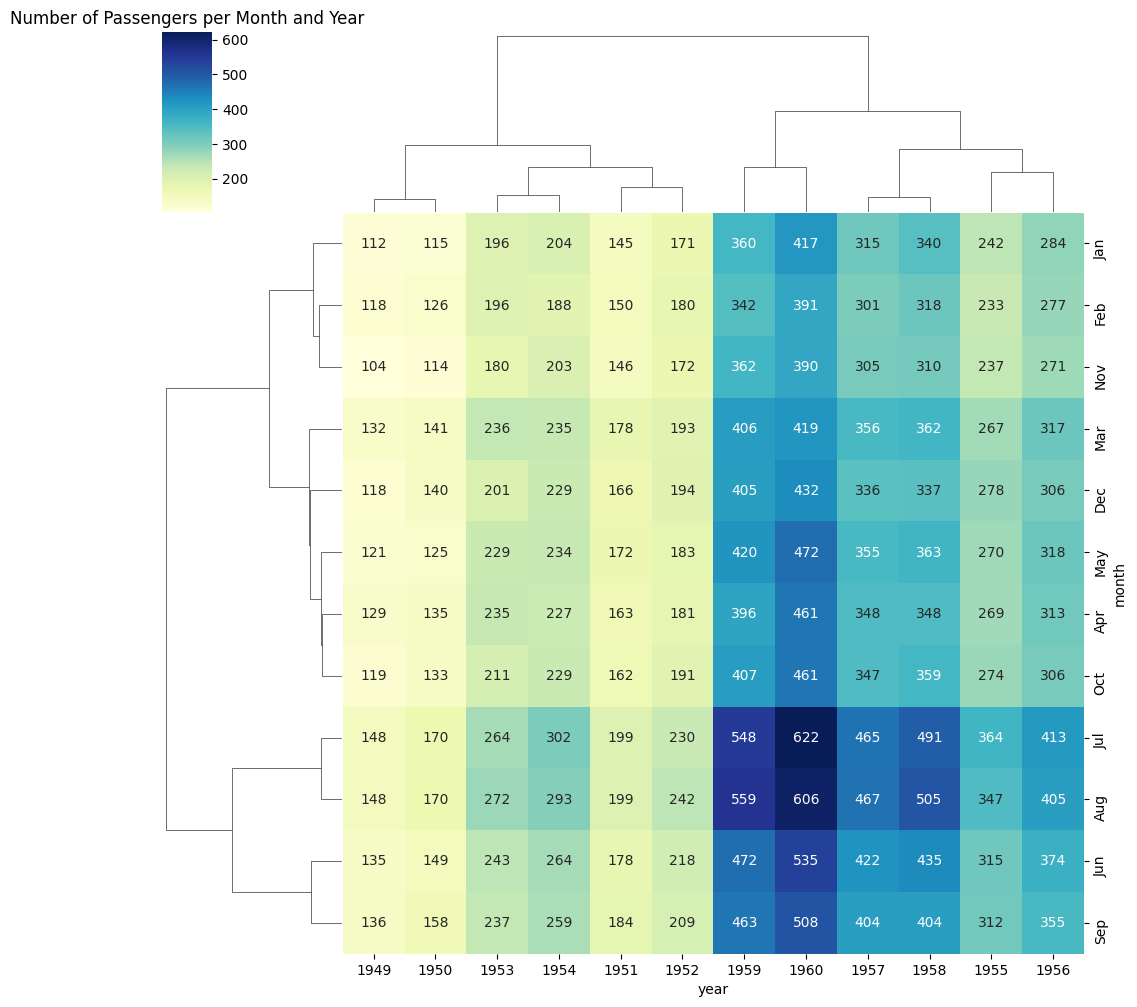

In [129]:
flights.clustermap = flights.pivot(index="month", columns="year", values="passengers")
sns.clustermap(flights.clustermap,annot=True, fmt="d", cmap="YlGnBu")
plt.title("Number of Passengers per Month and Year")